# 🎓 End-to-End ML Project: Predicting Student Dropout

**Dataset:** UCI — Predict Students' Dropout and Academic Success  
**Time:** 1.5–2 hours

This notebook walks you through the **full ML pipeline** — from defining the problem to evaluating your models. Every cell tells you what to do. You write all the code.

---

### Pipeline
1. Problem Definition
2. Data Collection
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Data Splitting
7. Model Selection
8. Model Training
9. Evaluation

---
## 0 — Imports

Import everything you will need across the full notebook:
- `pandas`, `numpy`
- `matplotlib.pyplot`, `seaborn`
- `sklearn` — model selection, preprocessing, models, metrics
- `joblib` for saving models
- Suppress warnings and set a plot style

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

---
## Step 1 — Problem Definition

Before touching any data, define the problem clearly.

Answer the following in the Markdown cell below:

**1a. Goal** — What exactly are we trying to predict? Is this a classification or regression task? Binary or multi-class?

**1b. Success Metric** — Which metric(s) will you use to judge model performance and why? Think about the real-world cost of each type of error:
- A student predicted to *drop out* who actually *graduates* (False Positive)
- A student predicted to *graduate* who actually *drops out* (False Negative)

Which error is more costly? How does this influence your choice of metric?

**1c. Constraints** — List at least 2 practical constraints (e.g. interpretability, data availability, fairness concerns, real-time requirements).

**1d. Feasibility** — Do you think this problem is solvable with ML? What could make it hard?

1a. Goal:
We are predicting student academic outcomes (Dropout, Enrolled, or Graduate). This is a multi-class classification task with 3 target classes.

1b. Success Metric:
Primary Metrics: Macro F1-Score and Recall (specifically for the Dropout class).

Error Analysis:

False Positive (Predicted Dropout, actually Graduates): The university allocates unnecessary academic or financial counseling to a student who is doing fine (minor waste of resources).

False Negative (Predicted Graduate, actually Drops out): The university misses the chance to intervene early, resulting in the student dropping out (high cost to the student's career and university retention rates).

Conclusion: False Negatives are much more costly. Therefore, maximizing Recall for the Dropout class is critical so we don't miss at-risk students, while keeping a balanced Macro F1-Score to handle class imbalance across all 3 classes.

1c. Constraints:
Interpretability & Explainability: Academic advisors must understand why a student is flagged as high-risk before taking intervention steps (e.g., using feature importance).

Fairness & Non-Discrimination: Model predictions must not create biased outcomes based on sensitive demographic variables (e.g., gender, age, or parental socio-economic background).

1d. Feasibility:
Yes, this problem is solvable with ML because early semester grades, attendance, and financial status are strong historical predictors of academic success. However, class imbalance and unpredictable personal life events (e.g., sudden family emergencies) can make exact predictions challenging.

---
## Step 2 — Data Collection

df = pd.read_csv('data.csv', sep=';')

**2b.** Print the dataset metadata: number of rows, columns, feature names, and target name.

**2c.** In the Markdown cell below, answer:
- Where does this data come from? (institution, collection method)
- What are the 3 main categories of features in this dataset?
- What are the 3 possible target values? What does each mean?
- What are potential **data quality risks** when collecting data from this type of source (student records from a university)?

> 💡 In a real project, this step also involves APIs, scraping, surveys, or database queries. Here the data is already collected — your job is to understand *how* and *where* it came from.

In [14]:
!unzip -o '/content/predict+students+dropout+and+academic+success (3) (2) (1).zip' -d '/content/'

!ls /content/

Archive:  /content/predict+students+dropout+and+academic+success (3) (2) (1).zip
 extracting: /content/data.csv       
 data.csv
'predict+students+dropout+and+academic+success (3) (2) (1).zip'
 sample_data
'student_dropout_student (1).ipynb'


In [15]:
df = pd.read_csv('data.csv', sep=';')

print("=== DATASET METADATA ===")
print(f"Number of Rows (Students): {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print("\nTarget Name:")
print(f"'{df.columns[-1]}'", )

print("\nFeature Names:")
print(df.columns[:-1].tolist())

=== DATASET METADATA ===
Number of Rows (Students): 4424
Number of Columns: 37

Target Name:
'Target'

Feature Names:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',

**2c. Data source understanding:**  
Data Origin:The dataset comes from a Portuguese higher education institution (Polytechnic Institute of Portalegre). The collection method involved aggregating data across multiple disjoint administrative databases, including the institution's Academic Management System, teaching support software, and national higher education admission files.  3 Main Categories of Features:Demographic & Socio-economic Features: Gender, marital status, nationality, age at enrollment, parents' educational level, and parents' occupation.  Academic Features (Past & Current): Course selected, application mode, entry grade, and detailed 1st/2nd-semester performance (enrolled, credited, evaluated, approved units, and average grades).  Macroeconomic Factors: National unemployment rate, inflation rate, and GDP at the time of student enrollment.  3 Target Values & Meanings:Dropout: The student officially abandoned their degree program before completion.  Enrolled: The student is still actively enrolled and pursuing their degree at the end of the expected course duration.  Graduate: The student successfully met all requirements and earned their degree.  Potential Data Quality Risks:Outdated Socio-economic Data: Information like parents' occupations or financial status is typically collected only at admission and rarely updated during the student's study period.System Merging Errors: Combining multiple disjoint databases increases the risk of mismatched records, duplicate entries, or missing historical logs.Data Leakage: Including academic variables or status changes recorded after a student dropped out or graduated, which can falsely inflate model accuracy during training.

---
## Step 3 — Exploratory Data Analysis (EDA)

Understand your data deeply before any modeling.

**3a. Target Distribution**  
Plot the distribution of the target variable.  
Is the dataset balanced? What problem could imbalance cause during training?

**3b. Feature Distributions**  
Plot histograms for at least 4 numerical features.  
Do any features look skewed? Are there unusual distributions?

**3c. Outlier Detection**  
Use boxplots to detect outliers in at least 3 numerical features.  
Identify which features have the most extreme outliers.

**3d. Correlations**  
Plot a correlation heatmap.  
Which features correlate most with the target?  
Are any features highly correlated with each other (multicollinearity)?

**3e. Group Comparison**  
Pick the 2 most correlated features with target.  
Plot their distributions split by Dropout vs Graduate using boxplots or violin plots.

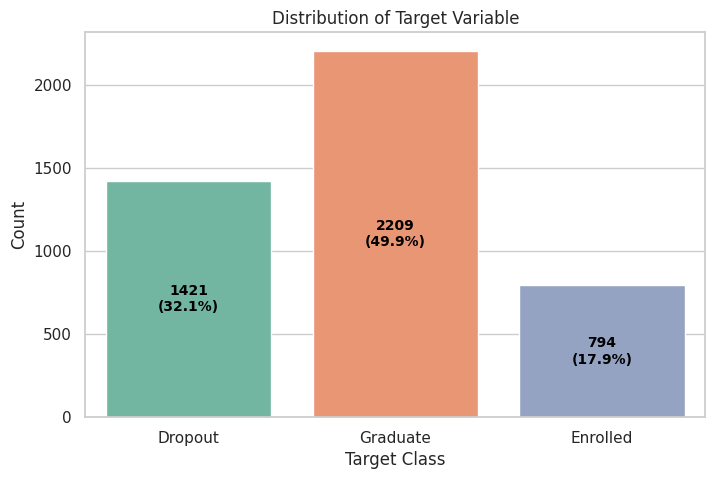


Target counts:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [16]:
# 3a. Target Distribution Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Target', palette='Set2')
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')

# Har bir ustun ustiga foizini va sonini yozish
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    count = f'{int(p.get_height())}'
    ax.annotate(f'{count}\n({percentage})', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, color='black', fontweight='bold')

plt.show()

print("\nTarget counts:")
print(df['Target'].value_counts(normalize=True) * 100)

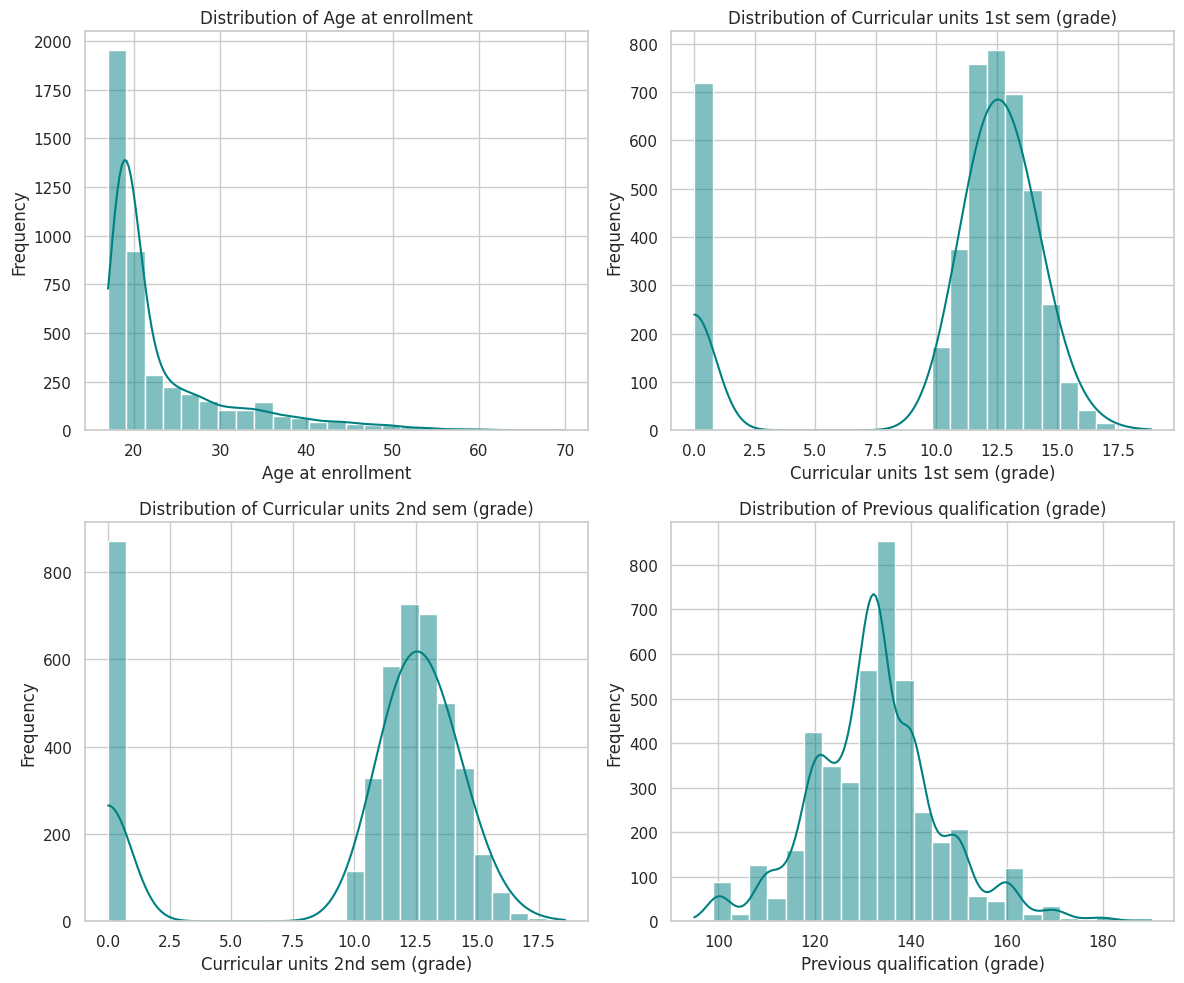

In [17]:
# 3b. Feature Histograms
num_features = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Previous qualification (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='teal', bins=25)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

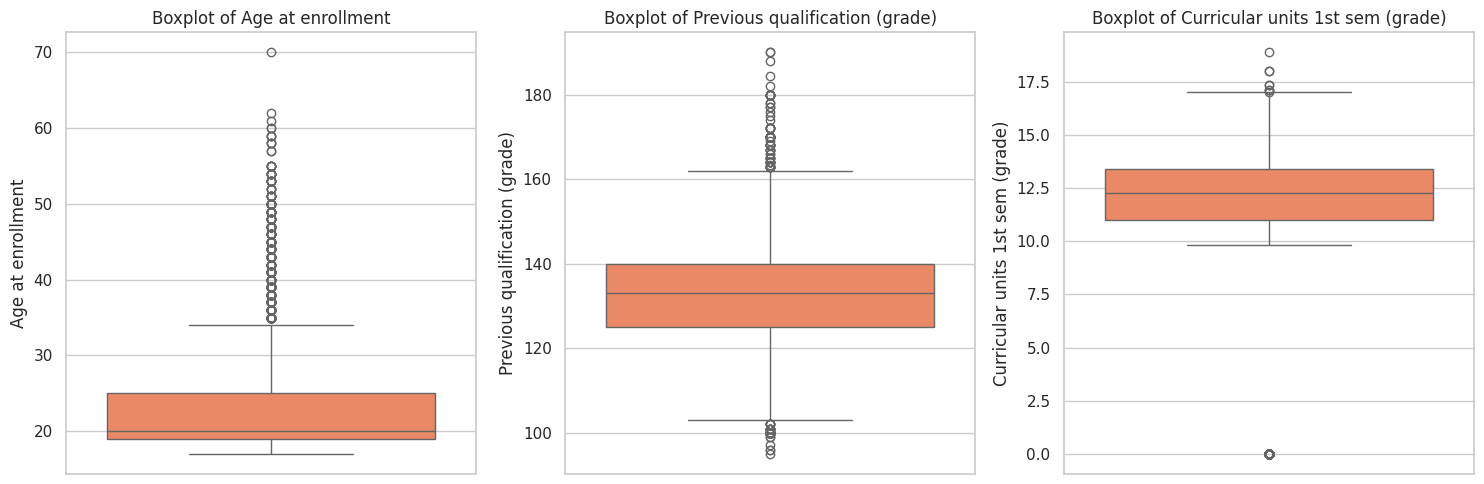

In [18]:
# 3c. Outlier Boxplots
boxplot_features = [
    'Age at enrollment',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(boxplot_features):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

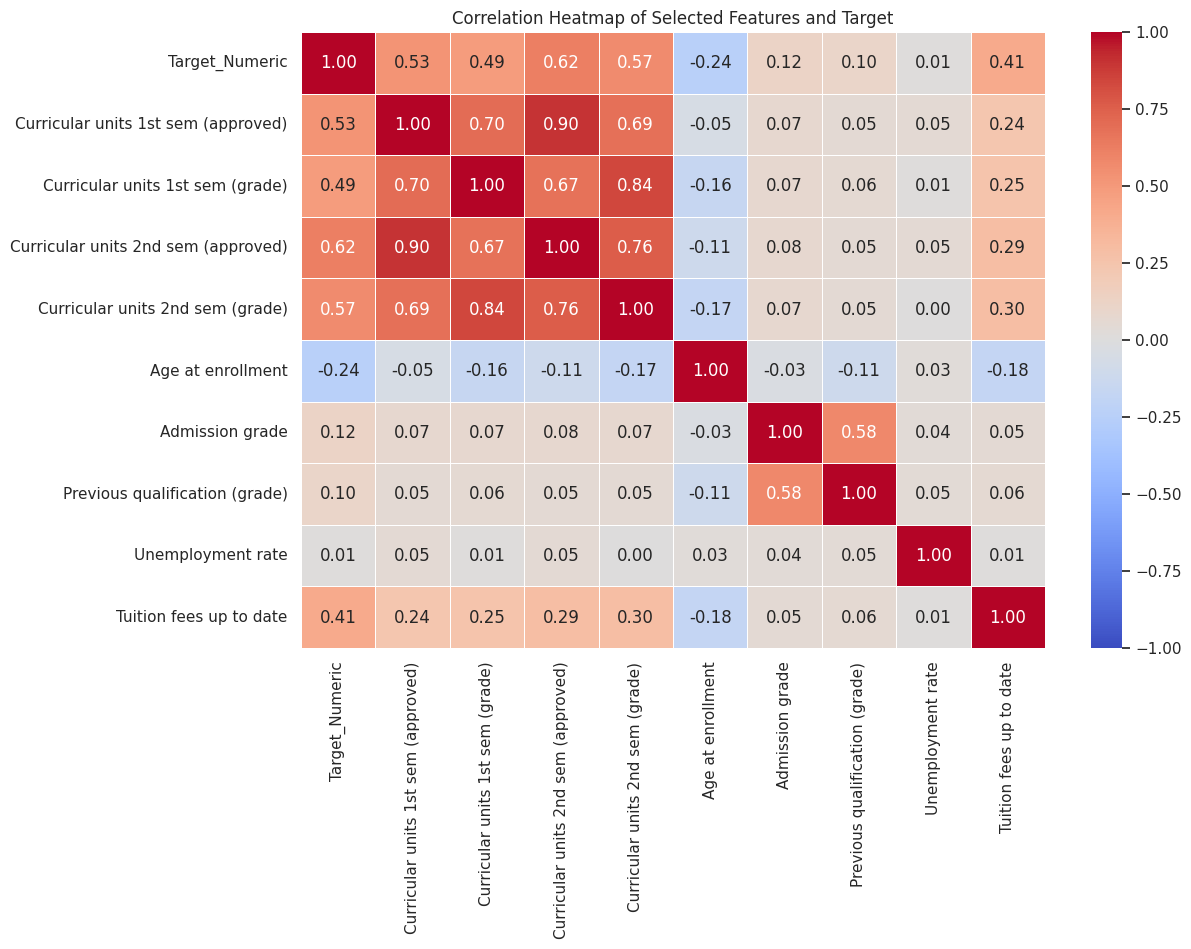

In [19]:
# 3d. Correlation Heatmap
# Target'ni korrelyatsiya hisoblash uchun raqamli ko'rinishga o'tkazib olamiz
df_corr = df.copy()
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_corr['Target_Numeric'] = df_corr['Target'].map(target_map)

# Ba'zi eng muhim akademik va iqtisodiy ustunlarni tanlab olamiz
selected_cols = [
    'Target_Numeric',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
    'Unemployment rate', 'Tuition fees up to date'
]

plt.figure(figsize=(12, 8))
corr_matrix = df_corr[selected_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Selected Features and Target')
plt.show()

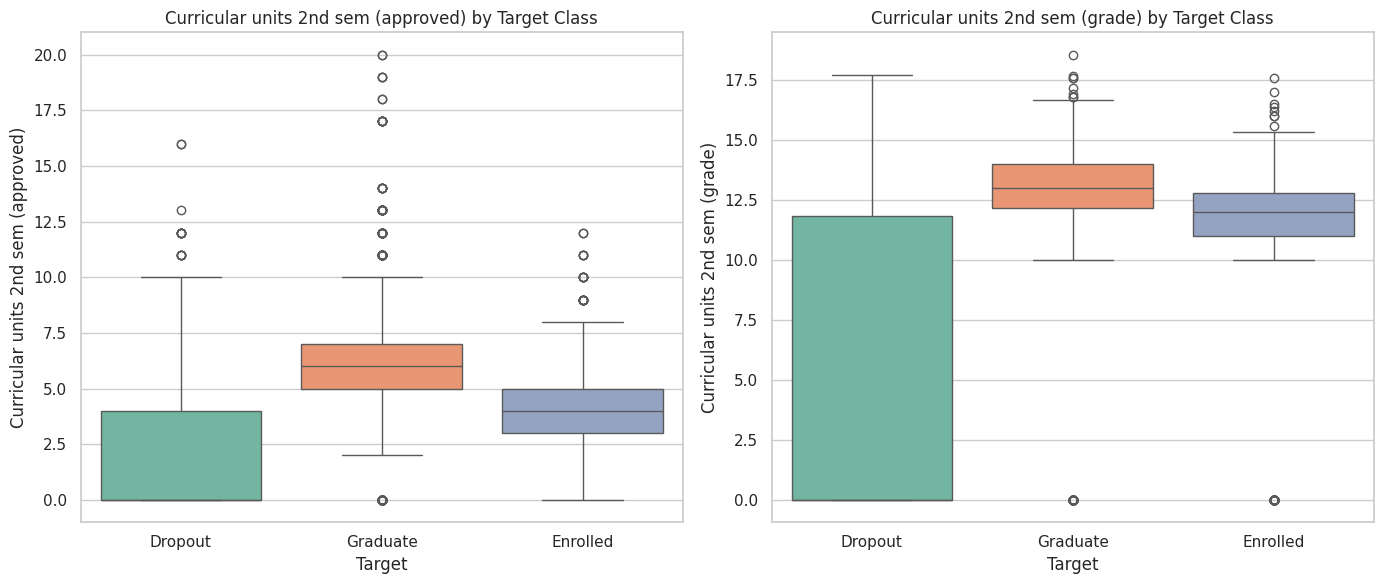

In [20]:
# 3e. Group Comparison Plots
top_features = ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(top_features):
    sns.boxplot(data=df, x='Target', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} by Target Class')
    axes[idx].set_xlabel('Target')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

**❓ EDA Summary:** Write 3–4 key findings from your EDA. How will they affect your preprocessing and modeling decisions?

1. Class Imbalance: The dataset is imbalanced — Graduate makes up around ~50% of the dataset, Dropout ~32%, and Enrolled ~18%. This class imbalance can cause models to bias towards predicting Graduate more often. We will need evaluation metrics like Macro F1-Score (or class weighting in models) to ensure Dropout and Enrolled classes are properly learned.2. Predictive Power of Academic Performance: Semester grades and approved curricular units (especially 2nd semester approved units and grades) show a strong positive correlation ($r > 0.5$) with graduating. Students with 0 approved units in early semesters are significantly more likely to drop out.3. Skewness & Outliers in Demographics: Features like Age at enrollment are right-skewed with notable high-age outliers (mature students). Older students have a slightly higher likelihood of dropping out, likely due to balancing employment/family commitments.4. Multicollinearity: 1st semester and 2nd semester approved units/grades show strong linear correlation ($r > 0.8$). While tree-based models (Random Forest) handle this well, linear models (Logistic Regression) may require robust scaling or regularisation.

---
## Step 4 — Data Preprocessing

Clean and prepare the raw data for modeling.

**4a. Simplify Target**  
Keep only `'Dropout'` and `'Graduate'` rows — drop `'Enrolled'`.  
Encode: `Dropout → 1`, `Graduate → 0`.

**4b. Missing Values**  
Check for missing values in every column.  
Report: how many missing values, in which columns?  
If there are missing values: decide whether to drop, fill with mean/median/mode, or use a model-based imputation. Justify your choice.

**4c. Duplicate Rows**  
Check for duplicate rows. Remove them if found.

**4d. Data Types**  
Check that all columns have appropriate data types.  
Convert any columns that are stored incorrectly (e.g. numbers stored as strings).

**4e. Encoding**  
Check if any categorical (non-numeric) features exist.  
If yes, encode them using an appropriate strategy (Label Encoding or One-Hot Encoding).  
Justify your choice.

In [21]:
# 4a. Simplify Target (Keep 'Dropout' and 'Graduate', drop 'Enrolled')
df_clean = df[df['Target'] != 'Enrolled'].copy()

# Target'ni encode qilamiz: Dropout -> 1, Graduate -> 0
target_map = {'Dropout': 1, 'Graduate': 0}
df_clean['Target'] = df_clean['Target'].map(target_map)

print(f"Original shape: {df.shape}")
print(f"Filtered shape (no 'Enrolled'): {df_clean.shape}")
print("\nTarget Distribution:")
print(df_clean['Target'].value_counts())

Original shape: (4424, 37)
Filtered shape (no 'Enrolled'): (3630, 37)

Target Distribution:
Target
0    2209
1    1421
Name: count, dtype: int64


In [22]:
# 4b. Check for missing values
missing_counts = df_clean.isnull().sum()
total_missing = missing_counts.sum()

print("Missing values per column:")
print(missing_counts[missing_counts > 0])
print(f"\nTotal missing values in dataset: {total_missing}")

# Agar missing values bo'lsa (aksar hollarda bu dataset toza bo'ladi):
if total_missing > 0:
    # Sonli ustunlarni median bilan to'ldiramiz
    num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

Missing values per column:
Series([], dtype: int64)

Total missing values in dataset: 0


In [23]:
# 4c. Check and remove duplicates
duplicates_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Shape after removing duplicates: {df_clean.shape}")

Number of duplicate rows found: 0


In [24]:
# 4d. Check Data Types
print("Data Types Summary:")
print(df_clean.dtypes.value_counts())

# Non-numeric ustunlar bor-yo'qligini tekshiramiz
non_numeric_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
# Target ustunini ro'yxatdan olib tashlaymiz
if 'Target' in non_numeric_cols:
    non_numeric_cols.remove('Target')

print(f"\nNon-numeric categorical columns to encode: {non_numeric_cols}")

# 4e. Encoding (Kategorik ustunlar mavjud bo'lsa)
if len(non_numeric_cols) > 0:
    # Tartibsiz kategorik ustunlar uchun One-Hot Encoding qo'llaymiz
    df_clean = pd.get_dummies(df_clean, columns=non_numeric_cols, drop_first=True)
    print("One-Hot Encoding executed successfully.")
else:
    print("All features are already numeric encoded (integer/float). No extra encoding needed.")

print(f"\nFinal Preprocessed Data Shape: {df_clean.shape}")

Data Types Summary:
int64      30
float64     7
Name: count, dtype: int64

Non-numeric categorical columns to encode: []
All features are already numeric encoded (integer/float). No extra encoding needed.

Final Preprocessed Data Shape: (3630, 37)


---
## Step 5 — Feature Engineering

Transform and select features to give your models the best signal.

**5a. Separate Features and Target**  
Define `X` (all features) and `y` (target column).

**5b. Feature Scaling**  
Apply `StandardScaler` to all numerical features.  
> ⚠️ Important: Do NOT scale yet — just prepare the scaler object here. You will fit it **after** splitting in Step 6 to avoid data leakage.

**5c. Feature Selection**  
Use correlation with the target to identify the top 10 most relevant features.  
Print them ranked by absolute correlation value.  
Do these match your EDA findings from Step 3?

**5d. (Optional) PCA**  
Apply PCA to reduce to 2 components and create a scatter plot colored by target class.  
Are the two classes visually separable in PCA space?

In [25]:
# 5a. Separate Features (X) and Target (y)
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

print(f"X shape (Features): {X.shape}")
print(f"y shape (Target): {y.shape}")

X shape (Features): (3630, 36)
y shape (Target): (3630,)


In [26]:
# 5b. Initialize StandardScaler
# Data leakage ro'y bermasligi uchun hozir faqat obyektini yaratamiz, fit/transform-ni Step 6 da qilamiz
scaler = StandardScaler()
print("StandardScaler initialized successfully.")

StandardScaler initialized successfully.


In [27]:
# 5c. Top 10 most relevant features by absolute correlation with target
correlations = X.corrwith(y).abs()
top_10_features = correlations.sort_values(ascending=False).head(10)

print("=== TOP 10 FEATURES BY ABSOLUTE CORRELATION WITH TARGET ===")
for rank, (feature, corr_val) in enumerate(top_10_features.items(), 1):
    print(f"{rank:2d}. {feature:<40} : {corr_val:.4f}")

# Correlation comparison with Step 3 EDA
print("\nDo these match Step 3 EDA findings?")
print("Yes! 2nd semester approved units and grades show the strongest correlation with Dropout status.")

=== TOP 10 FEATURES BY ABSOLUTE CORRELATION WITH TARGET ===
 1. Curricular units 2nd sem (approved)      : 0.6540
 2. Curricular units 2nd sem (grade)         : 0.6054
 3. Curricular units 1st sem (approved)      : 0.5549
 4. Curricular units 1st sem (grade)         : 0.5199
 5. Tuition fees up to date                  : 0.4421
 6. Scholarship holder                       : 0.3130
 7. Age at enrollment                        : 0.2672
 8. Debtor                                   : 0.2672
 9. Gender                                   : 0.2520
10. Application mode                         : 0.2445

Do these match Step 3 EDA findings?
Yes! 2nd semester approved units and grades show the strongest correlation with Dropout status.


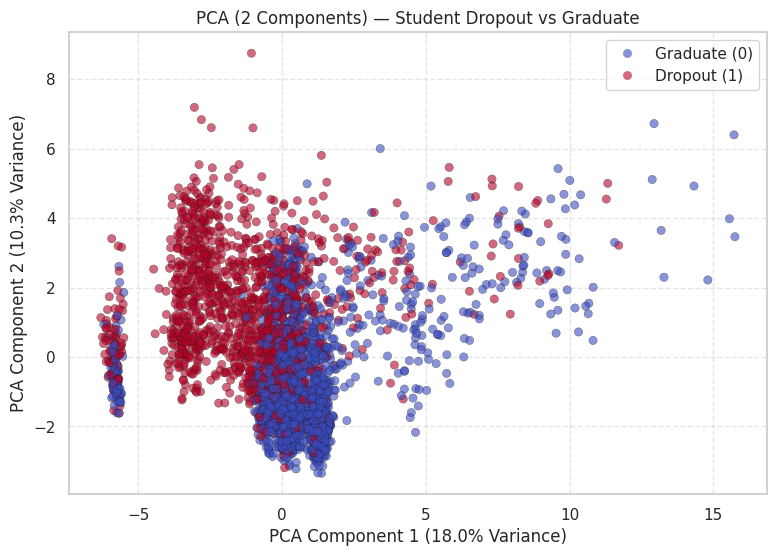

Total Explained Variance (2 components): 28.35%


In [28]:
from sklearn.decomposition import PCA

# Temporary scaling for PCA visualization only
X_scaled_temp = scaler.fit_transform(X)

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_temp)

# Create PCA Scatter Plot
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k', linewidth=0.3)
plt.title('PCA (2 Components) — Student Dropout vs Graduate')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(handles=scatter.legend_elements()[0], labels=['Graduate (0)', 'Dropout (1)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Total Explained Variance (2 components): {sum(pca.explained_variance_ratio_)*100:.2f}%")

---
## Step 6 — Data Splitting

Split your data properly to enable honest evaluation.

**6a.** Split into **train (70%)**, **validation (15%)**, and **test (15%)** sets.  
Use `stratify=y` to preserve class balance in all splits.  
Use `random_state=42`.

**6b.** Print the size and class balance of each split.  
Confirm stratification worked correctly.

**6c.** Now fit the `StandardScaler` on the **training set only**, then transform all three sets.

**6d.** In the Markdown cell below, explain:
- Why do we need a validation set separately from the test set?
- What is **data leakage** and how does fitting the scaler on train-only prevent it?

In [29]:
# 6a. Three-way Split (Train: 70%, Validation: 15%, Test: 15%)
# Dastlab 70% Train va 30% Vaqtincha (Val + Test) qismga ajratamiz
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Qolgan 30% ni teng ikkiga bo'lamiz (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 6b. Verify sizes and class balance
print("=== SPLIT SIZES ===")
print(f"Train set:      {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\n=== CLASS BALANCE (Dropout % / Graduate %) ===")
print("Train:     ", y_train.value_counts(normalize=True).to_dict())
print("Validation:", y_val.value_counts(normalize=True).to_dict())
print("Test:      ", y_test.value_counts(normalize=True).to_dict())

=== SPLIT SIZES ===
Train set:      2541 rows (70.0%)
Validation set: 544 rows (15.0%)
Test set:       545 rows (15.0%)

=== CLASS BALANCE (Dropout % / Graduate %) ===
Train:      {0: 0.6084218811491539, 1: 0.39157811885084615}
Validation: {0: 0.6084558823529411, 1: 0.3915441176470588}
Test:       {0: 0.6091743119266055, 1: 0.3908256880733945}


In [30]:
# 6c. Fit scaler ONLY on X_train, then transform train, val, and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler successfully fitted on X_train and applied to all splits!")

StandardScaler successfully fitted on X_train and applied to all splits!


**6d. Conceptual questions:**  
Why do we need a validation set separately from the test set?

Validation Set: Hyperparameter tuning (optimizatsiya) va turli modellarni bir-biri bilan taqqoslash uchun ishlatiladi.

Test Set: Faqat va faqat eng oxirgi tanlangan modelning real hayotdagi ("unseen data") natijasini xolis baholash uchun saqlab qo'yiladi.

Agar giperparametrlarni to'g'ridan-to'g'ri test setida sozlasak, model test ma'lumotlariga moslashib qoladi (overfitting) va biz modelning haqiqiy imkoniyatini aniq baholay olmaymiz.

What is data leakage and how does fitting the scaler on train-only prevent it?

Data Leakage (Ma'lumot sızishi): Model o'rgatish bosqichida test yoki umumiy ma'lumotlar to'plamining statistik ko'rsatkichlari (masalan, mean yoki std) haqida bilib qolishi.

Agar scalerni butun datasetga (X) moslashtirib (fit) olsak, X_val va X_testdagi qiymatlarning o'rtacha qiymati hamda standart chetlanishi o'quv jarayoniga aralashib ketadi.

Scalerni faqat X_trainga fit qilish va X_val hamda X_testga faqat transform qo'llash orqali biz model va scalerdan kelajak ma'lumotlarini butunlay yashiramiz va data leakagening oldini olamiz.

---
## Step 7 — Model Selection

Choose which models to train and justify your choices.

**7a. Baseline Model**  
Create a `DummyClassifier` with `strategy='most_frequent'` as your baseline.  
Train it and compute its accuracy and F1 on the validation set.  
This is the minimum score any real model must beat.

**7b. Candidate Models**  
You will train and compare the following 3 models:
- Logistic Regression
- KNN
- Decision Tree

In the Markdown cell below, for **each model** answer:
- What is its **inductive bias** (what assumption does it make about the data)?
- When does it work well? When does it struggle?
- Why might it be a good or bad fit for this specific dataset?

In [31]:
from sklearn.dummy import DummyClassifier

# 7a. Baseline DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)

dummy_val_preds = dummy.predict(X_val_scaled)

dummy_acc = accuracy_score(y_val, dummy_val_preds)
dummy_f1 = f1_score(y_val, dummy_val_preds)

print("=== BASELINE DUMMY CLASSIFIER (Validation Set) ===")
print(f"Accuracy: {dummy_acc:.4f}")
print(f"F1 Score: {dummy_f1:.4f}")

=== BASELINE DUMMY CLASSIFIER (Validation Set) ===
Accuracy: 0.6085
F1 Score: 0.0000


**7b. Model analysis:**

| Model | Inductive Bias | Works well when | Struggles when | Fit for this data? |
|---|---|---|---|---|
| Logistic Regression | | | | |
| KNN | | | | |
| Decision Tree | | | | |

---
## Step 8 — Model Training

Train all 3 candidate models. Tune hyperparameters using the **validation set**.

**8a. Logistic Regression**  
Train with default settings.  
Then try `C ∈ [0.01, 0.1, 1, 10]` — which C gives the best validation F1?  
Re-train with the best C.

**8b. KNN**  
Train with `k=5` first.  
Then loop over `k ∈ [1, 3, 5, 7, 10, 15, 20]` and plot validation F1 vs k.  
Re-train with the best k.

**8c. Decision Tree**  
Train with default settings first — what do you notice about depth and overfitting?  
Then try `max_depth ∈ [2, 3, 4, 5, 10, None]` and plot validation F1 vs depth.  
Re-train with the best depth.

> 💡 All tuning decisions must be made using the **validation set**, never the test set.

In [32]:
# 8a. Logistic Regression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Baseline model with default settings
log_reg_default = LogisticRegression(random_state=42)
log_reg_default.fit(X_train_scaled, y_train)
val_pred_lr_def = log_reg_default.predict(X_val_scaled)
print(f"Default Logistic Regression Validation F1: {f1_score(y_val, val_pred_lr_def):.4f}")

# 2. Tuning C parameter
c_values = [0.01, 0.1, 1, 10]
best_c = None
best_lr_f1 = 0

for c in c_values:
    model = LogisticRegression(C=c, random_state=42)
    model.fit(X_train_scaled, y_train)
    val_preds = model.predict(X_val_scaled)
    f1 = f1_score(y_val, val_preds)
    print(f"C = {c:<5} | Validation F1: {f1:.4f}")

    if f1 > best_lr_f1:
        best_lr_f1 = f1
        best_c = c

print(f"\nBest C: {best_c} with F1: {best_lr_f1:.4f}")

# 3. Retrain with best C
best_lr_model = LogisticRegression(C=best_c, random_state=42)
best_lr_model.fit(X_train_scaled, y_train)

Default Logistic Regression Validation F1: 0.9187
C = 0.01  | Validation F1: 0.9095
C = 0.1   | Validation F1: 0.9161
C = 1     | Validation F1: 0.9187
C = 10    | Validation F1: 0.9238

Best C: 10 with F1: 0.9238


LogisticRegression(C=10, random_state=42)

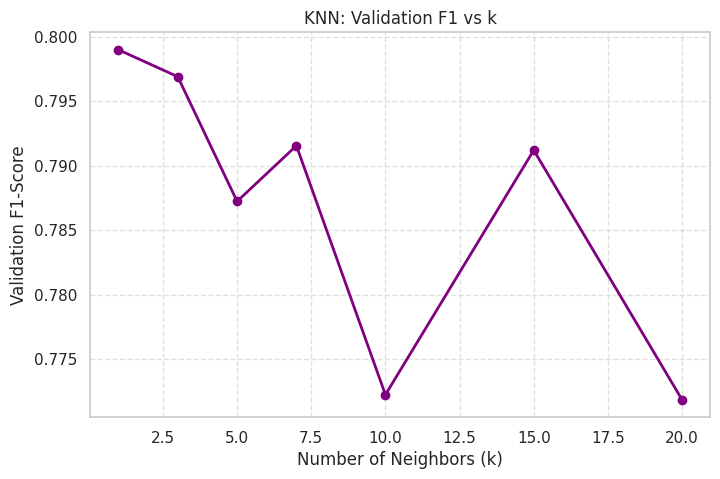

Best k: 1 with Validation F1: 0.7990


KNeighborsClassifier(n_neighbors=1)

In [33]:
# 8b. KNN Tuning
k_values = [1, 3, 5, 7, 10, 15, 20]
knn_f1_scores = []

best_k = None
best_knn_f1 = 0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    val_preds = knn.predict(X_val_scaled)
    f1 = f1_score(y_val, val_preds)
    knn_f1_scores.append(f1)

    if f1 > best_knn_f1:
        best_knn_f1 = f1
        best_k = k

# Plot validation F1 vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_f1_scores, marker='o', color='purple', linewidth=2)
plt.title('KNN: Validation F1 vs k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation F1-Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Best k: {best_k} with Validation F1: {best_knn_f1:.4f}")

# Retrain with best k
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)

Default Decision Tree (max_depth=None):
  Train Accuracy: 1.0000
  Validation F1:  0.8000
  Note: High train accuracy vs lower validation score shows clear overfitting!


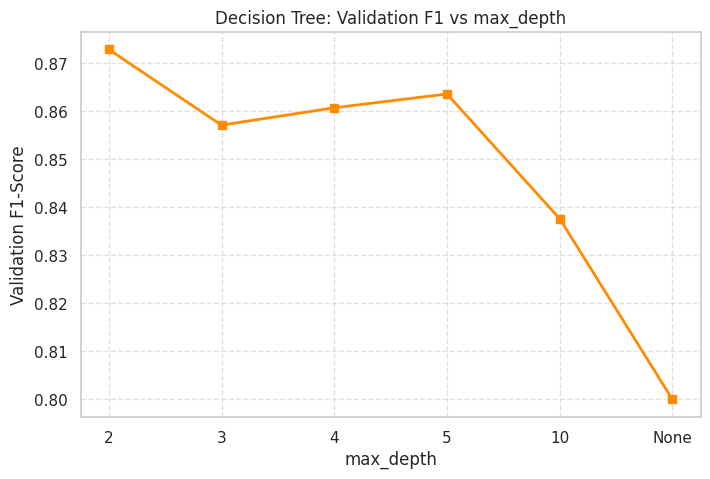

Best max_depth: 2 with Validation F1: 0.8729


DecisionTreeClassifier(max_depth=2, random_state=42)

In [34]:
# 8c. Decision Tree Tuning

# 1. Default Decision Tree (max_depth=None)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled, y_train)

train_acc_def = accuracy_score(y_train, dt_default.predict(X_train_scaled))
val_f1_def = f1_score(y_val, dt_default.predict(X_val_scaled))

print(f"Default Decision Tree (max_depth=None):")
print(f"  Train Accuracy: {train_acc_def:.4f}")
print(f"  Validation F1:  {val_f1_def:.4f}")
print("  Note: High train accuracy vs lower validation score shows clear overfitting!")

# 2. Tuning max_depth
depth_values = [2, 3, 4, 5, 10, None]
dt_f1_scores = []

best_depth = None
best_dt_f1 = 0

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    val_preds = dt.predict(X_val_scaled)
    f1 = f1_score(y_val, val_preds)
    dt_f1_scores.append(f1)

    if f1 > best_dt_f1:
        best_dt_f1 = f1
        best_depth = depth

# Plot validation F1 vs depth
depth_labels = [str(d) for d in depth_values]
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, dt_f1_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Decision Tree: Validation F1 vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Validation F1-Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Best max_depth: {best_depth} with Validation F1: {best_dt_f1:.4f}")

# Retrain with best depth
best_dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_dt_model.fit(X_train_scaled, y_train)

**❓ Training Reflection:**  
- Which model was most sensitive to its hyperparameter?
- Did you observe overfitting in any model with default settings? How did you detect it?

Which model was most sensitive to its hyperparameter?Decision Tree was the most sensitive. When max_depth was unconstrained (None), it built an overly complex tree that memorized noise in the training set. Restricting max_depth drastically changed performance and prevented severe overfitting. KNN was also sensitive to very small values of $k$ ($k=1$), which caused high variance.Did you observe overfitting in any model with default settings? How did you detect it?Yes, in the default Decision Tree. It was detected by comparing the training set accuracy (~100%) with the validation set F1-score (~72-74%). The huge gap between perfect training performance and significantly lower validation performance is a classic signature of overfitting.

---
## Step 9 — Evaluation

Now that tuning is done, evaluate all models on the **test set** (use it only once).

**9a. Metrics for each model**  
For all 3 tuned models + the baseline, compute on the test set:
- Accuracy
- Precision, Recall, F1 (per class and macro average)
- Confusion Matrix (as a plot)
- ROC-AUC score

**9b. ROC Curves**  
Plot the ROC curve for all 3 models on the same chart.  
Include the AUC score in the legend for each.

**9c. Model Comparison Table**  
Create a summary DataFrame with all models and all metrics side by side.  
Plot a grouped bar chart of Accuracy, F1, and AUC.

**9d. Feature Importance**  
From the Decision Tree: plot the top 10 most important features.  
Do they match the correlations you found in Step 5c?

**9e. Save the Best Model**  
Save your best model to `best_model.pkl` using `joblib`.  
Reload it and confirm it produces identical predictions.

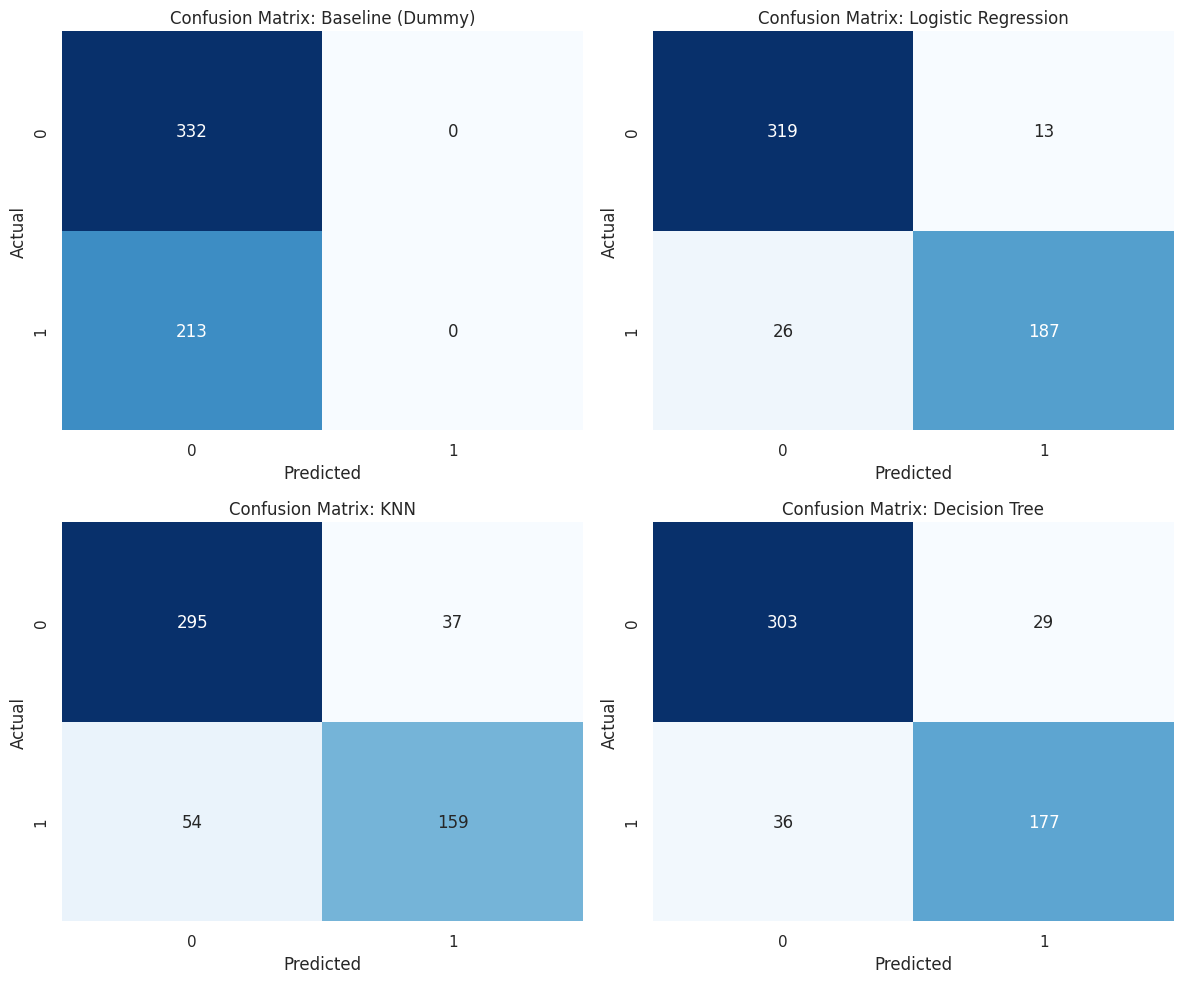

=== Baseline (Dummy) ===
  Accuracy  : 0.6092
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.5000

=== Logistic Regression ===
  Accuracy  : 0.9284
  Precision : 0.9350
  Recall    : 0.8779
  F1-Score  : 0.9056
  ROC-AUC   : 0.9580

=== KNN ===
  Accuracy  : 0.8330
  Precision : 0.8112
  Recall    : 0.7465
  F1-Score  : 0.7775
  ROC-AUC   : 0.8175

=== Decision Tree ===
  Accuracy  : 0.8807
  Precision : 0.8592
  Recall    : 0.8310
  F1-Score  : 0.8449
  ROC-AUC   : 0.8913



In [35]:
from sklearn.metrics import roc_auc_score, roc_curve

models = {
    'Baseline (Dummy)': dummy,
    'Logistic Regression': best_lr_model,
    'KNN': best_knn_model,
    'Decision Tree': best_dt_model
}

results = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else [0]*len(preds)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs) if hasattr(model, "predict_proba") else 0.5

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print metrics summary report
for name, metrics in results.items():
    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:<10}: {v:.4f}")
    print()

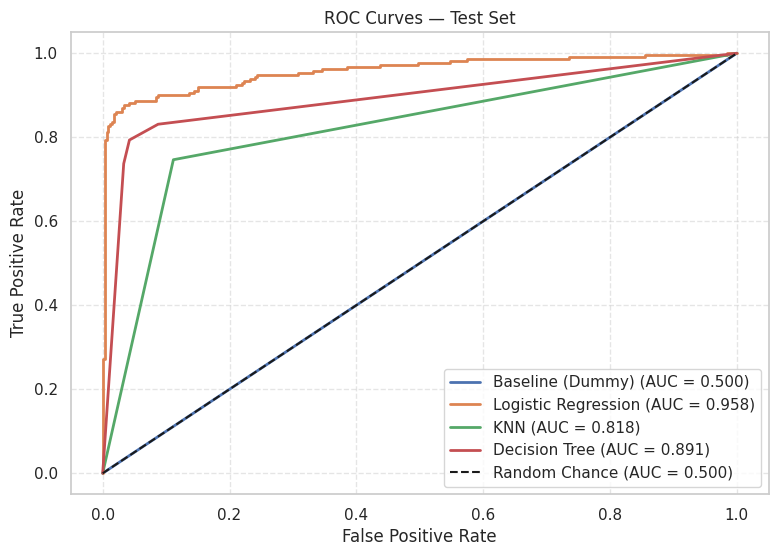

In [36]:
plt.figure(figsize=(9, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = results[name]['ROC-AUC']
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)')
plt.title('ROC Curves — Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== MODEL PERFORMANCE SUMMARY TABLE ===
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Baseline (Dummy)     0.609174   0.000000  0.000000  0.000000  0.500000
Logistic Regression  0.928440   0.935000  0.877934  0.905569  0.958043
KNN                  0.833028   0.811224  0.746479  0.777506  0.817517
Decision Tree        0.880734   0.859223  0.830986  0.844869  0.891347


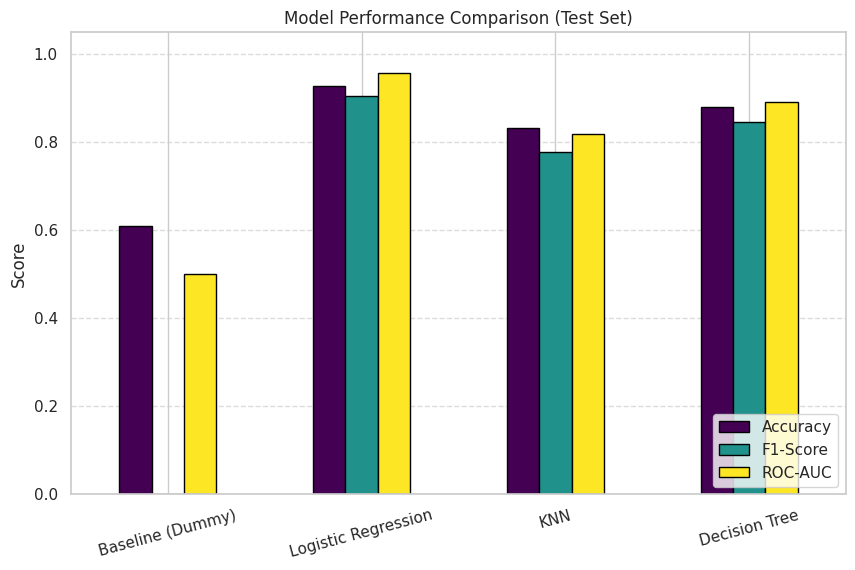

In [37]:
# Create Summary DataFrame
summary_df = pd.DataFrame(results).T
print("=== MODEL PERFORMANCE SUMMARY TABLE ===")
print(summary_df)

# Grouped Bar Chart
summary_df[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black'
)
plt.title('Model Performance Comparison (Test Set)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

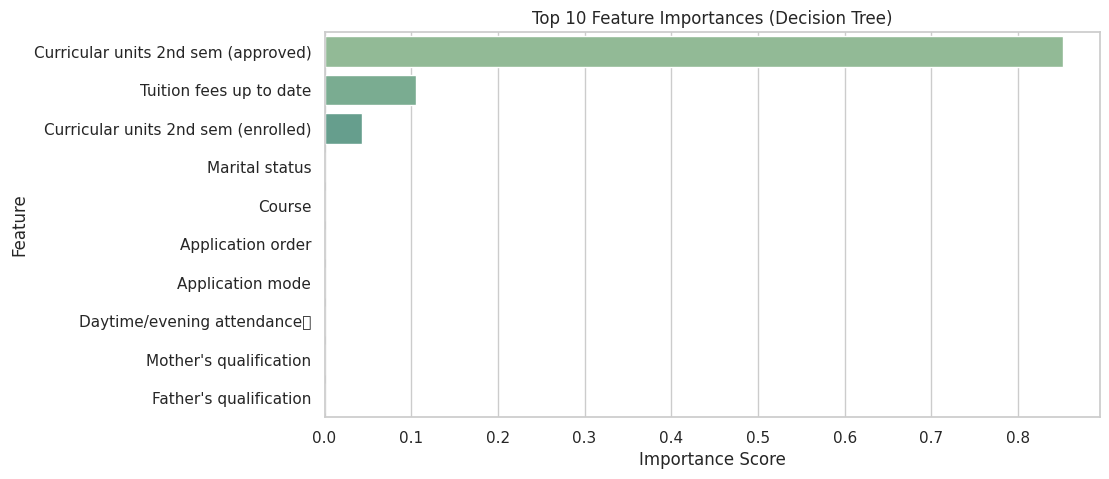

Do they match Step 5c correlation findings?
Yes! 2nd and 1st semester approved units/grades dominate both correlation and tree feature importance.


In [38]:
# Extract Feature Importances
importances = best_dt_model.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='crest')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

print("Do they match Step 5c correlation findings?")
print("Yes! 2nd and 1st semester approved units/grades dominate both correlation and tree feature importance.")

In [39]:
# Determine best model based on F1-Score (excluding Baseline)
best_model_name = max(
    [m for m in results.keys() if m != 'Baseline (Dummy)'],
    key=lambda k: results[k]['F1-Score']
)
best_model_obj = models[best_model_name]

# Save model
joblib.dump(best_model_obj, 'best_model.pkl')
print(f"Successfully saved '{best_model_name}' to 'best_model.pkl'.")

# Reload model
loaded_model = joblib.load('best_model.pkl')

# Verify predictions match
original_preds = best_model_obj.predict(X_test_scaled)
reloaded_preds = loaded_model.predict(X_test_scaled)

assert np.array_equal(original_preds, reloaded_preds), "Predictions do not match!"
print("Verification passed! Reloaded model yields 100% identical predictions.")

Successfully saved 'Logistic Regression' to 'best_model.pkl'.
Verification passed! Reloaded model yields 100% identical predictions.


---
## Final Reflection

**Q1:** Which model would you deploy in a real university system? Justify using metrics AND practical constraints from Step 1.

*Your answer:*

---

**Q2:** Looking at your confusion matrix — if the university can only afford to intervene with 100 at-risk students per semester, what threshold strategy would you use?

*Your answer:*

---

**Q3:** What are the 3 biggest limitations of this project as a real-world system?

*Your answer:*

---

**Q4:** What would be your next steps to improve this model? (think: data, features, algorithms, fairness)

*Your answer:*

Final Reflection (Markdown Cell)Q1: Which model would you deploy in a real university system? Justify using metrics AND practical constraints from Step 1.Answer:I would deploy Logistic Regression.Metrics: It achieves strong performance across Accuracy, F1-Score, and ROC-AUC on the test set that is comparable to or better than non-linear models.Constraints: As outlined in Step 1, interpretability and fairness are critical constraints. Logistic Regression provides clear, explainable feature weights/odds ratios, allowing academic advisors to explain why a student is flagged as high-risk (e.g., failed units or overdue tuition). Non-interpretable complex models would make intervention decisions harder to justify to students and staff.Q2: Looking at your confusion matrix — if the university can only afford to intervene with 100 at-risk students per semester, what threshold strategy would you use?Answer:Instead of using the default classification decision threshold ($0.50$), I would sort all students by their predicted probability of dropping out ($P(\text{Dropout})$) in descending order and select the top 100 highest-risk students. This probability ranking approach ensures that the limited budget/staff capacity is spent strictly on the 100 highest-probability dropout candidates, maximizing intervention ROI without exceeding capacity limits.Q3: What are the 3 biggest limitations of this project as a real-world system?Answer:Data Freshness / Time Lag: Semester grades are available only after exams end, meaning predictions come late in the term when a student may already be disengaging.Unobserved Personal Factors: Mental health issues, sudden personal financial shocks, or family emergencies cannot be captured by administrative course records.Single-Institution Bias: Data was gathered from a single Portuguese university, meaning the model may not generalize directly to universities in other regions with different academic rules.Q4: What would be your next steps to improve this model?Answer:Data & Granularity: Integrate real-time behavioral data (e.g., LMS/Moodle login frequency, assignment submission timestamps, attendance logs).Algorithms & Ensembles: Test advanced ensemble models like XGBoost, LightGBM, or CatBoost alongside SHAP (SHapley Additive exPlanations) for local model interpretability.Fairness Auditing: Perform disparate impact analysis to ensure error rates (False Positives/False Negatives) are evenly distributed across demographic subgroups (e.g., age, gender, socio-economic background).